# Week 2: Machine Learning Basics

머신러닝의 핵심 개념을 직접 구현하며 학습한 5개의 실습 기록입니다.

---

## Lab 1 - 선형 회귀: 스프링 실험 (TensorFlow)

훅의 법칙(`길이 = 2 × 무게 + 10`)을 모르는 상태에서 측정 데이터만으로 TensorFlow가 규칙을 스스로 학습합니다.

기울기(w): 2.0612  (실제: 2.0)
절편(b):   9.7123  (실제: 10.0)
무게 6.5kg 예측 길이: 23.11 cm


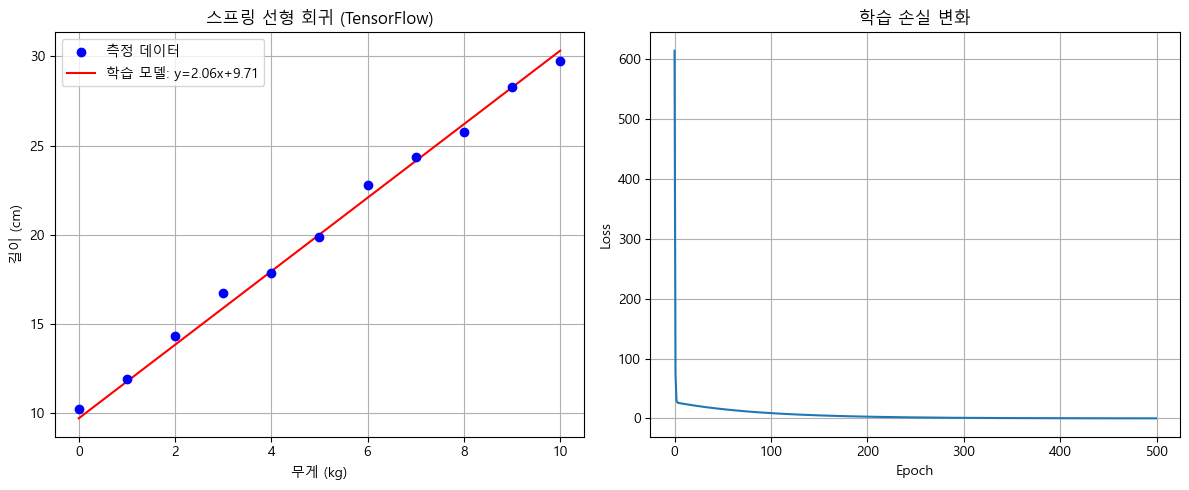

In [2]:
# Lab 1: Linear Regression - Spring (TensorFlow)
# 훅의 법칙: 무게에 따른 스프링 길이 예측

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 생성
np.random.seed(42)
weights = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
true_lengths = 2 * weights + 10          # 실제 법칙: 길이 = 2 * 무게 + 10
noise = np.random.normal(0, 0.5, len(weights))
measured_lengths = true_lengths + noise  # 측정값 (노이즈 포함)

print("=== 스프링 데이터 ===")
print(f"무게(kg): {weights}")
print(f"측정 길이(cm): {np.round(measured_lengths, 2)}")

# 2. TensorFlow 모델 생성
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

model.compile(
    optimizer='sgd',
    loss='mean_squared_error'
)

# 3. 학습
print("\n=== 모델 학습 중... ===")
history = model.fit(weights, measured_lengths, epochs=500, verbose=0)

# 4. 결과 확인
learned_w = model.layers[0].get_weights()[0][0][0]
learned_b = model.layers[0].get_weights()[1][0]
print(f"\n학습된 파라미터:")
print(f"  기울기(w): {learned_w:.4f}  (실제: 2.0)")
print(f"  절편(b):   {learned_b:.4f}  (실제: 10.0)")

# 5. 예측
test_weight = 6.5
predicted_length = model.predict(np.array([test_weight]), verbose=0)[0][0]
print(f"\n무게 {test_weight}kg 일 때 예측 길이: {predicted_length:.2f} cm")

# 6. 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(weights, measured_lengths, color='blue', label='측정 데이터', zorder=5)
x_line = np.linspace(0, 10, 100)
y_line = learned_w * x_line + learned_b
ax1.plot(x_line, y_line, color='red', label=f'학습된 모델: y={learned_w:.2f}x+{learned_b:.2f}')
ax1.set_xlabel('무게 (kg)')
ax1.set_ylabel('길이 (cm)')
ax1.set_title('스프링 선형 회귀 (TensorFlow)')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'])
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (MSE)')
ax2.set_title('학습 손실 변화')
ax2.grid(True)

plt.tight_layout()
plt.savefig('C:/Users/A/OneDrive/Desktop/aicoursework/week2/01_result.png', dpi=100)
plt.show()
print("\n결과 이미지 저장: 01_result.png")


---
## Lab 2 - 비지도학습: K-Means 클러스터링

레이블(정답) 없이 데이터의 패턴만으로 자동 군집화합니다. NumPy로 K-Means를 직접 구현합니다.

총 데이터: 90개, 단 3번 반복만에 수렴
  클러스터 1: 11개, 중심=[5.2  8.63]
  클러스터 2: 19개, 중심=[4.83 7.84]
  클러스터 3: 60개, 중심=[4.94 2.48]


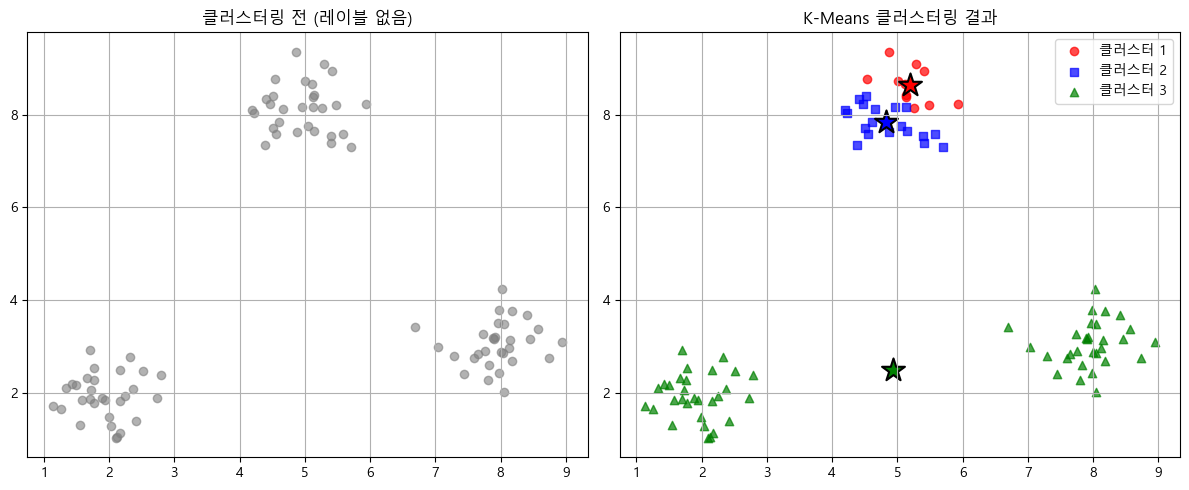

In [4]:
# Lab 2: Unsupervised Learning - K-Means Clustering
# 레이블 없이 데이터를 자동으로 군집화

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 1. 데이터 생성 (3개 그룹)
group1 = np.random.normal(loc=[2, 2], scale=0.5, size=(30, 2))
group2 = np.random.normal(loc=[8, 3], scale=0.5, size=(30, 2))
group3 = np.random.normal(loc=[5, 8], scale=0.5, size=(30, 2))
X = np.vstack([group1, group2, group3])

print("=== K-Means 클러스터링 ===")
print(f"총 데이터 포인트: {len(X)}개")

# 2. K-Means 직접 구현
k = 3
# 초기 중심점: 데이터에서 랜덤 선택
idx = np.random.choice(len(X), k, replace=False)
centers = X[idx].copy()

labels = None
for iteration in range(50):
    # (a) 각 점을 가장 가까운 중심에 할당
    distances = np.sqrt(((X - centers[:, np.newaxis])**2).sum(axis=2))
    new_labels = np.argmin(distances, axis=0)

    # (b) 수렴 확인
    if labels is not None and np.all(new_labels == labels):
        print(f"  수렴 완료 (iteration {iteration})")
        break
    labels = new_labels

    # (c) 중심점 업데이트
    centers = np.array([X[labels == j].mean(axis=0) for j in range(k)])

# 3. 결과 출력
for j in range(k):
    count = np.sum(labels == j)
    print(f"  클러스터 {j+1}: {count}개 포인트, 중심={np.round(centers[j], 2)}")

# 4. 시각화
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 클러스터링 전
ax1.scatter(X[:, 0], X[:, 1], color='gray', alpha=0.6)
ax1.set_title('클러스터링 전 (레이블 없음)')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.grid(True)

# 클러스터링 후
for j in range(k):
    mask = labels == j
    ax2.scatter(X[mask, 0], X[mask, 1], c=colors[j], marker=markers[j],
                alpha=0.7, label=f'클러스터 {j+1}')
    ax2.scatter(centers[j, 0], centers[j, 1], c=colors[j],
                marker='*', s=300, edgecolors='black', linewidths=1.5)

ax2.set_title('K-Means 클러스터링 결과')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('C:/Users/A/OneDrive/Desktop/aicoursework/week2/02_result.png', dpi=100)
plt.show()
print("결과 이미지 저장: 02_result.png")


---
## Lab 3 - 데이터 전처리: Min-Max 정규화

스케일이 다른 특성들을 `[0, 1]` 범위로 통일합니다.

공식: `x_norm = (x - x_min) / (x_max - x_min)`

연봉 범위: 31,440,915 ~ 97,893,690원  →  0.0 ~ 1.0
나이 범위: 20.2 ~ 59.5세  →  0.0 ~ 1.0
스케일 차이: 약 1,692,866배  →  동등


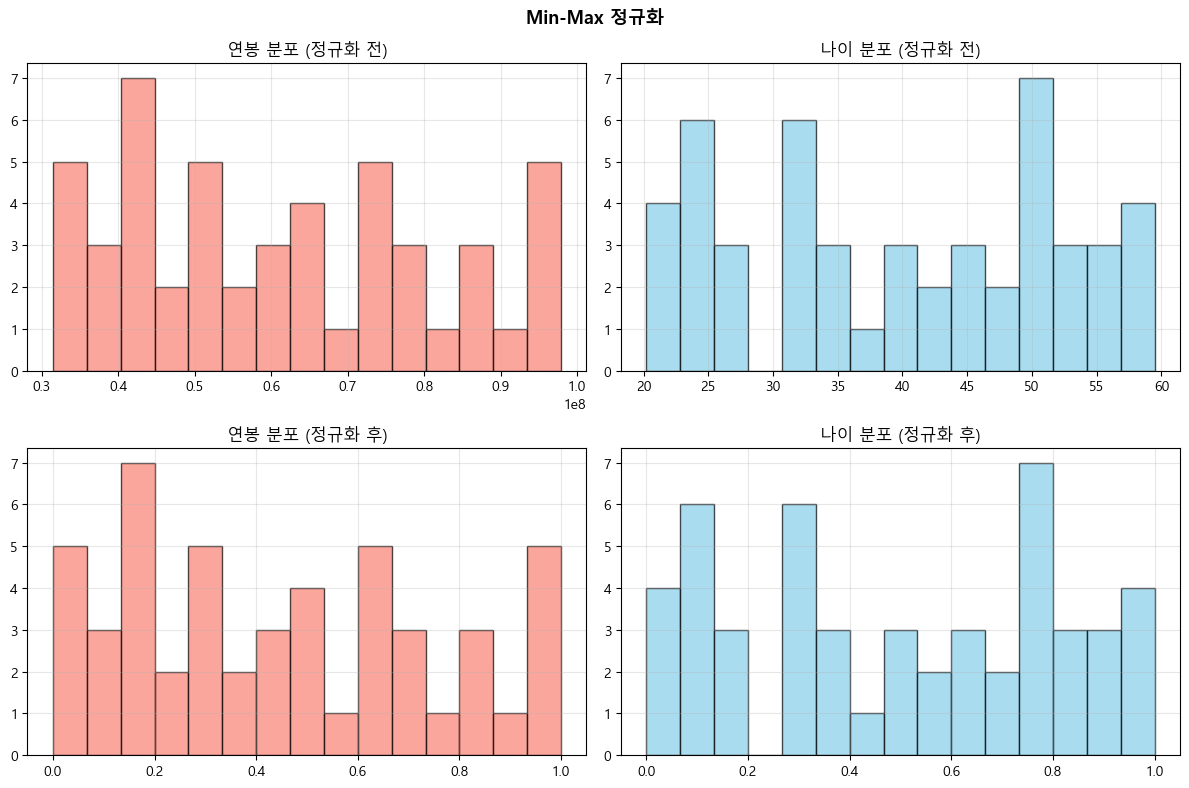

In [6]:
# Lab 3: Data Preprocessing - Normalization
# 데이터 정규화: 서로 다른 스케일의 데이터를 0~1 범위로 통일

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 1. 원본 데이터 생성 (스케일이 완전히 다른 두 특성)
salary = np.random.uniform(30_000_000, 100_000_000, 50)  # 연봉 (3천만~1억원)
age    = np.random.uniform(20, 60, 50)                    # 나이 (20~60세)

print("=== 정규화 전 ===")
print(f"연봉 - 최소: {salary.min():,.0f}원, 최대: {salary.max():,.0f}원, 평균: {salary.mean():,.0f}원")
print(f"나이 - 최소: {age.min():.1f}세, 최대: {age.max():.1f}세, 평균: {age.mean():.1f}세")

# 2. Min-Max 정규화
# 공식: (x - min) / (max - min) → 결과 범위 [0, 1]
salary_normalized = (salary - salary.min()) / (salary.max() - salary.min())
age_normalized    = (age    - age.min())    / (age.max()    - age.min())

print("\n=== 정규화 후 ===")
print(f"연봉 - 최소: {salary_normalized.min():.4f}, 최대: {salary_normalized.max():.4f}, 평균: {salary_normalized.mean():.4f}")
print(f"나이 - 최소: {age_normalized.min():.4f},    최대: {age_normalized.max():.4f},    평균: {age_normalized.mean():.4f}")

# 3. 정규화의 효과 확인
print("\n=== 왜 정규화가 필요한가? ===")
print("정규화 전 연봉과 나이의 스케일 차이:")
print(f"  연봉 범위: {salary.max() - salary.min():,.0f}")
print(f"  나이 범위: {age.max() - age.min():.1f}")
print(f"  스케일 비율: {(salary.max()-salary.min())/(age.max()-age.min()):,.0f}배")
print("→ 이 차이로 인해 ML 모델이 연봉에만 편향되어 학습됨")
print("→ 정규화 후 두 특성 모두 0~1 범위로 동등하게 취급")

# 4. 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 정규화 전
axes[0, 0].hist(salary, bins=15, color='salmon', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('연봉 분포 (정규화 전)')
axes[0, 0].set_xlabel('연봉 (원)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(age, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('나이 분포 (정규화 전)')
axes[0, 1].set_xlabel('나이 (세)')
axes[0, 1].grid(True, alpha=0.3)

# 정규화 후
axes[1, 0].hist(salary_normalized, bins=15, color='salmon', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('연봉 분포 (정규화 후)')
axes[1, 0].set_xlabel('정규화된 값 [0, 1]')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(age_normalized, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('나이 분포 (정규화 후)')
axes[1, 1].set_xlabel('정규화된 값 [0, 1]')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Min-Max 정규화: (x - min) / (max - min)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/A/OneDrive/Desktop/aicoursework/week2/03_result.png', dpi=100)
plt.show()
print("\n결과 이미지 저장: 03_result.png")


---
## Lab 4 - 경사하강법 시각화

AI 학습의 핵심 메커니즘입니다.

공식: `x_new = x - learning_rate × gradient(x)`

학습률=0.1, 시작 x=8.0
30번 반복 후 최종 x=0.009904, loss=0.00009808


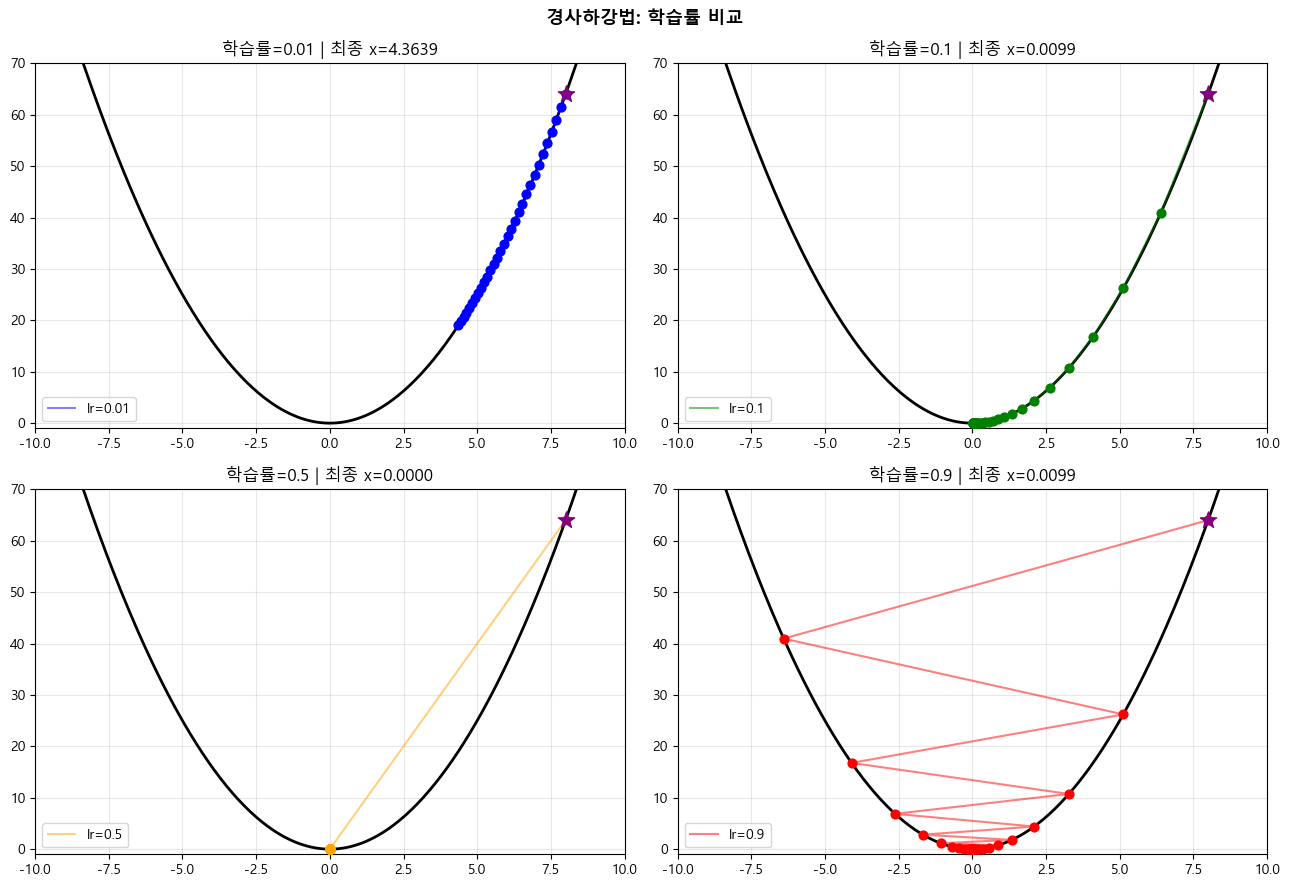

In [8]:
# Lab 4: Gradient Descent Visualization
# 경사하강법: AI가 최솟값을 찾아가는 핵심 메커니즘

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 손실 함수 정의
def loss_function(x):
    return x ** 2          # f(x) = x²  (최솟값: x=0)

def gradient(x):
    return 2 * x           # f'(x) = 2x

# 2. 경사하강법 실행
learning_rate = 0.1
start_x = 8.0             # 시작점

history_x = [start_x]
history_loss = [loss_function(start_x)]

current_x = start_x
for i in range(30):
    grad = gradient(current_x)
    current_x = current_x - learning_rate * grad
    history_x.append(current_x)
    history_loss.append(loss_function(current_x))

print("=== 경사하강법 ===")
print(f"학습률(Learning Rate): {learning_rate}")
print(f"시작점: x = {start_x}")
print(f"\n{'Iter':>4}  {'x':>10}  {'Loss':>12}  {'Gradient':>10}")
print("-" * 45)
for i in range(0, min(10, len(history_x))):
    g = gradient(history_x[i])
    print(f"{i:>4}  {history_x[i]:>10.4f}  {history_loss[i]:>12.6f}  {g:>10.4f}")
print(f"  ...")
print(f"{len(history_x)-1:>4}  {history_x[-1]:>10.6f}  {history_loss[-1]:>12.8f}  (수렴)")
print(f"\n최종 최솟값: x = {history_x[-1]:.6f}, loss = {history_loss[-1]:.8f}")

# 3. 학습률 비교
lr_list = [0.01, 0.1, 0.5, 0.9]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

x_range = np.linspace(-10, 10, 300)
colors = ['blue', 'green', 'orange', 'red']

for ax, lr, color in zip(axes.flatten(), lr_list, colors):
    cx = 8.0
    hx, hl = [cx], [loss_function(cx)]
    for _ in range(30):
        cx = cx - lr * gradient(cx)
        hx.append(cx)
        hl.append(loss_function(cx))

    ax.plot(x_range, loss_function(x_range), 'k-', linewidth=2, label='f(x) = x²')
    ax.scatter(hx, [loss_function(v) for v in hx], c=color, s=40, zorder=5)
    ax.plot(hx, [loss_function(v) for v in hx], c=color, alpha=0.5,
            label=f'경로 (lr={lr})')
    ax.scatter(hx[0], loss_function(hx[0]), c='purple', s=150, zorder=6,
               marker='*', label='시작점')
    ax.set_title(f'학습률 = {lr}  |  최종 x = {hx[-1]:.3f}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-1, 70)

plt.suptitle('경사하강법: 학습률(Learning Rate)에 따른 수렴 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/A/OneDrive/Desktop/aicoursework/week2/04_result.png', dpi=100)
plt.show()
print("결과 이미지 저장: 04_result.png")


---
## Lab 5 - SciPy를 이용한 수치 최적화

TensorFlow(반복 경사하강법) vs SciPy(수학적 최적화 BFGS)를 비교합니다.

[curve_fit] a=1.9767, b=10.2991  (실제: 2.0, 10.0)
[minimize]  x=2.000000, f(x)=1.000000  (반복 3회)


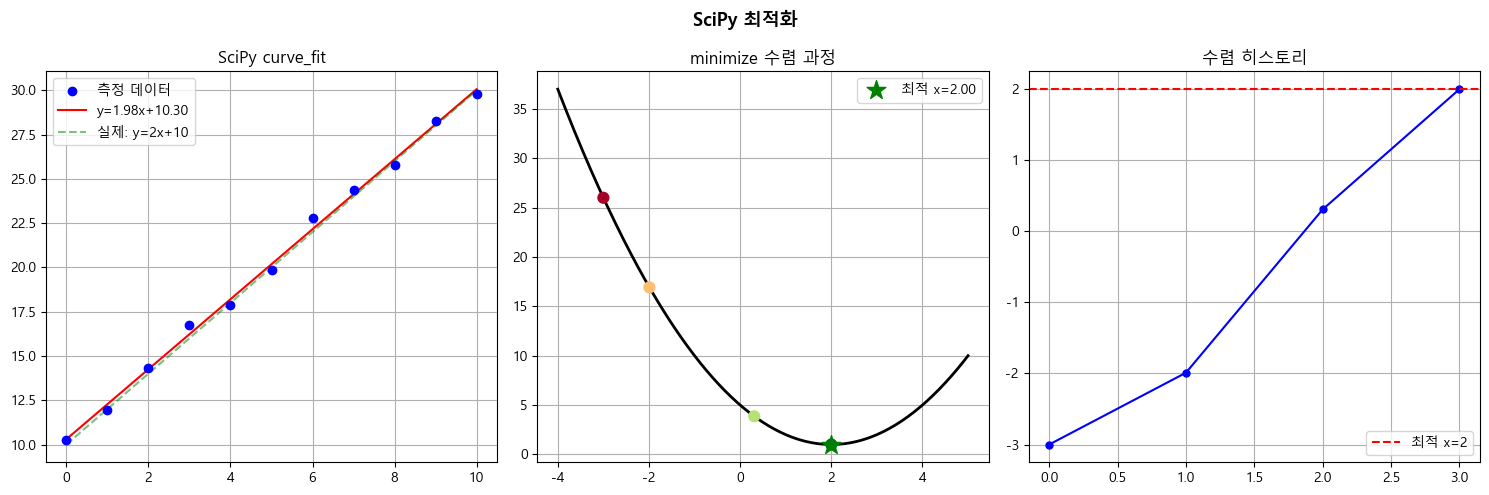

In [10]:
# Lab 5: SciPy를 이용한 최적화
# TensorFlow(반복 학습) vs SciPy(수학적 직접 해법) 비교

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, curve_fit

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ──────────────────────────────────────────────
# Part A: SciPy로 스프링 선형 회귀
# ──────────────────────────────────────────────
print("=== Part A: SciPy curve_fit으로 스프링 회귀 ===")

np.random.seed(42)
weights = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
true_lengths = 2 * weights + 10
noise = np.random.normal(0, 0.5, len(weights))
measured_lengths = true_lengths + noise

def linear_func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(linear_func, weights, measured_lengths)
learned_a, learned_b = popt
perr = np.sqrt(np.diag(pcov))

print(f"학습된 기울기(a): {learned_a:.4f} ± {perr[0]:.4f}  (실제: 2.0)")
print(f"학습된 절편(b):   {learned_b:.4f} ± {perr[1]:.4f}  (실제: 10.0)")

# ──────────────────────────────────────────────
# Part B: SciPy minimize로 수치 최적화
# ──────────────────────────────────────────────
print("\n=== Part B: SciPy minimize로 수치 최적화 ===")

def objective_func(x):
    return (x[0] - 2) ** 2 + 1   # 최솟값: x=2, f(x)=1

history = []
def callback(x):
    history.append(float(x[0]))

result = minimize(objective_func, x0=[-3.0], method='BFGS', callback=callback)
history.insert(0, -3.0)  # 시작점 추가

print(f"시작점: x = -3.0")
print(f"최적 x: {result.x[0]:.6f}  (이론값: 2.0)")
print(f"최솟값 f(x): {result.fun:.6f}  (이론값: 1.0)")
print(f"반복 횟수: {result.nit}")
print(f"수렴 성공: {result.success}")

# ──────────────────────────────────────────────
# Part C: TensorFlow vs SciPy 비교
# ──────────────────────────────────────────────
print("\n=== Part C: TensorFlow vs SciPy 비교 ===")
print(f"{'항목':<20} {'TensorFlow':<20} {'SciPy':<20}")
print("-" * 60)
print(f"{'접근 방식':<20} {'반복적 경사하강법':<20} {'수학적 최적화':<20}")
print(f"{'학습 epoch':<20} {'500회 필요':<20} {f'{result.nit}회':<20}")
print(f"{'유연성':<20} {'복잡한 모델 가능':<20} {'간단한 함수 적합':<20}")
print(f"{'용도':<20} {'딥러닝':<20} {'수치 해석':<20}")

# ──────────────────────────────────────────────
# 시각화
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (1) 스프링 curve_fit 결과
axes[0].scatter(weights, measured_lengths, color='blue', label='측정 데이터', zorder=5)
x_line = np.linspace(0, 10, 100)
axes[0].plot(x_line, linear_func(x_line, learned_a, learned_b), 'r-',
             label=f'SciPy: y={learned_a:.2f}x+{learned_b:.2f}')
axes[0].plot(x_line, 2 * x_line + 10, 'g--', alpha=0.5, label='실제: y=2x+10')
axes[0].set_title('SciPy curve_fit - 스프링 회귀')
axes[0].set_xlabel('무게 (kg)')
axes[0].set_ylabel('길이 (cm)')
axes[0].legend()
axes[0].grid(True)

# (2) minimize 수렴 과정
x_range = np.linspace(-4, 5, 200)
axes[1].plot(x_range, (x_range - 2)**2 + 1, 'k-', linewidth=2, label='f(x)=(x-2)²+1')
axes[1].scatter(history, [(v - 2)**2 + 1 for v in history],
                c=range(len(history)), cmap='RdYlGn', s=60, zorder=5)
axes[1].scatter(history[0], (history[0]-2)**2+1, c='red', s=200, marker='*',
                zorder=6, label=f'시작: x={history[0]:.1f}')
axes[1].scatter(result.x[0], result.fun, c='green', s=200, marker='*',
                zorder=6, label=f'최적: x={result.x[0]:.2f}')
axes[1].set_title('SciPy minimize - 최적화 수렴 과정')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()
axes[1].grid(True)

# (3) 수렴 히스토리
axes[2].plot(history, 'b-o', markersize=5)
axes[2].axhline(y=2.0, color='r', linestyle='--', label='최적값 x=2')
axes[2].set_title('최적화 수렴 히스토리')
axes[2].set_xlabel('반복 횟수')
axes[2].set_ylabel('x 값')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('SciPy 최적화: curve_fit & minimize', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/A/OneDrive/Desktop/aicoursework/week2/05_result.png', dpi=100)
plt.show()
print("\n결과 이미지 저장: 05_result.png")


---
## 핵심 학습 내용 정리

| 개념 | 설명 | 관련 Lab |
|-----|-----|---------|
| **지도학습** | 레이블(정답)이 있는 데이터로 규칙 학습 | Lab 1, 5 |
| **비지도학습** | 레이블 없이 데이터 패턴 자동 발견 | Lab 2 |
| **데이터 전처리** | 데이터 준비가 모델 성능의 80%를 결정 | Lab 3 |
| **경사하강법** | AI 학습의 핵심 최적화 메커니즘 | Lab 4 |
| **프레임워크 비교** | 딥러닝(TF) vs 수치해석(SciPy) 장단점 | Lab 5 |

## 실행 환경
- Python 3.13 / TensorFlow 2.21.0 / NumPy, SciPy, Matplotlib